In [1]:
import os

os.makedirs("../csv", exist_ok=True)
os.makedirs("../svg", exist_ok=True)

In [2]:
import matplotlib.pyplot as plt
import seaborn as sns
import scienceplots
import pandas as pd
import numpy as np
from scipy.stats import theilslopes
from scipy.stats import gmean

In [3]:
plt.rcParams.update({
    'font.family': 'TeX Gyre Termes',
    'font.size': 10,
    'axes.labelsize': 10,
    'axes.titlesize': 11,
    'figure.dpi': 300,
    'savefig.dpi': 300,
})

In [4]:
TEXTWIDTH_PT = 426.79137
TEXTHEIGHT_PT = 702.78308
PT_PER_INCH = 72.27

FIG_WIDTH = TEXTWIDTH_PT / PT_PER_INCH
FIG_HEIGHT_1 = TEXTHEIGHT_PT / PT_PER_INCH
FIG_HEIGHT_2 = FIG_HEIGHT_1 / 2
FIG_HEIGHT_3 = FIG_HEIGHT_1 / 3
FIG_HEIGHT_4 = FIG_HEIGHT_1 / 4
FIG_HEIGHT_5 = FIG_HEIGHT_1 / 5
FIG_HEIGHT_6 = FIG_HEIGHT_1 / 6
FIG_HEIGHT_7 = FIG_HEIGHT_1 / 7
FIG_HEIGHT_8 = FIG_HEIGHT_1 / 8

In [5]:
criterion_x86 = pd.read_csv('../data/criterion_x86.csv')
criterion_aarch64 = pd.read_csv('../data/criterion_aarch64.csv')

In [6]:
def get_speck(df):
    speck = df[df['benchmark'] == 'speck']
    speck = speck.drop(columns=['benchmark', 'suffix', 'unit', 'throughput_type'])
    speck['time_per_iter_ns'] = speck['sample_measured_value'] / speck['iteration_count']

    speck['keys_per_sec'] = (
            speck['throughput_num'] / (speck['time_per_iter_ns'] / 1e9)
    )
    return speck

In [7]:
speck_x86 = get_speck(criterion_x86)
speck_aarch64 = get_speck(criterion_aarch64)

In [8]:
def regression(df, group_cols):
    results = []

    for keys, group in df.groupby(group_cols):
        x = group['iteration_count'].values
        y = group['sample_measured_value'].values

        slope, intercept, ci_low, ci_high = theilslopes(y, x, 0.95)

        y_pred = slope * x + intercept
        ss_res = np.sum((y - y_pred) ** 2)
        ss_tot = np.sum((y - np.mean(y)) ** 2)
        r2 = 1 - ss_res / ss_tot

        keys_per_iter = group['throughput_num'].iloc[0]
        keys_per_sec = keys_per_iter / (slope / 1e9)

        results.append({
            **dict(zip(group_cols, keys)),
            'time_per_iter_ns': slope,
            'ci_95_low_ns': ci_low,
            'ci_95_high_ns': ci_high,
            'intercept_ns': intercept,
            'r2': r2,
            'keys_per_sec': keys_per_sec,
            'Mkeys_per_sec': keys_per_sec / 1e6,
        })

    return pd.DataFrame(results)

In [9]:
speck_reg_x86 = regression(speck_x86, ['backend', 'architecture', 'function', 'version'])
speck_reg_aarch64 = regression(speck_aarch64, ['backend', 'architecture', 'function', 'version'])

In [10]:
import os
import numpy as np

version_order = ['32_64', '48_72', '48_96', '64_96', '64_128',
                 '96_96', '96_144', '128_128', '128_192', '128_256']


def fmt_val_pct(x, up, dn):
    if pd.isna(x) or x <= 0:
        return "--"
    if pd.isna(up) or pd.isna(dn):
        return rf"\({x:.2f}\)"
    return rf"\({x:.2f}\,(^{{+{up:.1f}\%}}_{{-{dn:.1f}\%}})\)"


def make_speck_latex_pivot(df, backend_order):
    d = df.copy()
    d['up_pct'] = (d['time_per_iter_ns'] / d['ci_95_low_ns'] - 1.0) * 100
    d['dn_pct'] = (1.0 - d['time_per_iter_ns'] / d['ci_95_high_ns']) * 100
    d['cell'] = [fmt_val_pct(x, up, dn)
                 for x, up, dn in zip(d['Mkeys_per_sec'], d['up_pct'], d['dn_pct'])]

    pivot = d.pivot_table(
        index=['backend', 'version'],
        columns='function',
        values='cell',
        aggfunc='first',
    ).reset_index()
    pivot.columns.name = None
    pivot['backend'] = pd.Categorical(pivot['backend'], categories=backend_order, ordered=True)
    pivot['version'] = pd.Categorical(pivot['version'], categories=version_order, ordered=True)
    return pivot.sort_values(['backend', 'version']).reset_index(drop=True)

In [11]:
speck_latex_x86 = make_speck_latex_pivot(speck_reg_x86, ['scalar', 'sse2', 'avx2', 'avx512'])
speck_latex_x86.to_csv("../csv/speck_results_x86.csv", index=False)

In [12]:
speck_latex_aarch64 = make_speck_latex_pivot(speck_reg_aarch64, ['scalar', 'neon'])
speck_latex_aarch64.to_csv("../csv/speck_results_x86.csv", index=False)

In [13]:
def make_speck_pivot_mean(reg_df, backend_order, fmt=False):
    funcs = ['decrypt', 'encrypt', 'encrypt_inflight']
    d = reg_df[reg_df['function'].isin(funcs)].copy()

    d['mkeys'] = d['Mkeys_per_sec']
    d['mkeys_hi'] = d['Mkeys_per_sec'] * d['time_per_iter_ns'] / d['ci_95_low_ns']
    d['mkeys_lo'] = d['Mkeys_per_sec'] * d['time_per_iter_ns'] / d['ci_95_high_ns']

    g = (d.groupby(['backend', 'function'])[['mkeys', 'mkeys_lo', 'mkeys_hi']]
         .agg(gmean).reset_index())
    g['up_pct'] = (g['mkeys_hi'] / g['mkeys'] - 1.0) * 100
    g['dn_pct'] = (1.0 - g['mkeys_lo'] / g['mkeys']) * 100

    def piv(col):
        p = g.pivot(index='backend', columns='function', values=col)
        p.columns.name = None
        p = p.reindex(columns=funcs)
        p.index = pd.Categorical(p.index, categories=backend_order, ordered=True)
        return p.sort_index()

    if fmt == 'ci':
        return piv('mkeys'), piv('up_pct'), piv('dn_pct')
    return piv('mkeys')

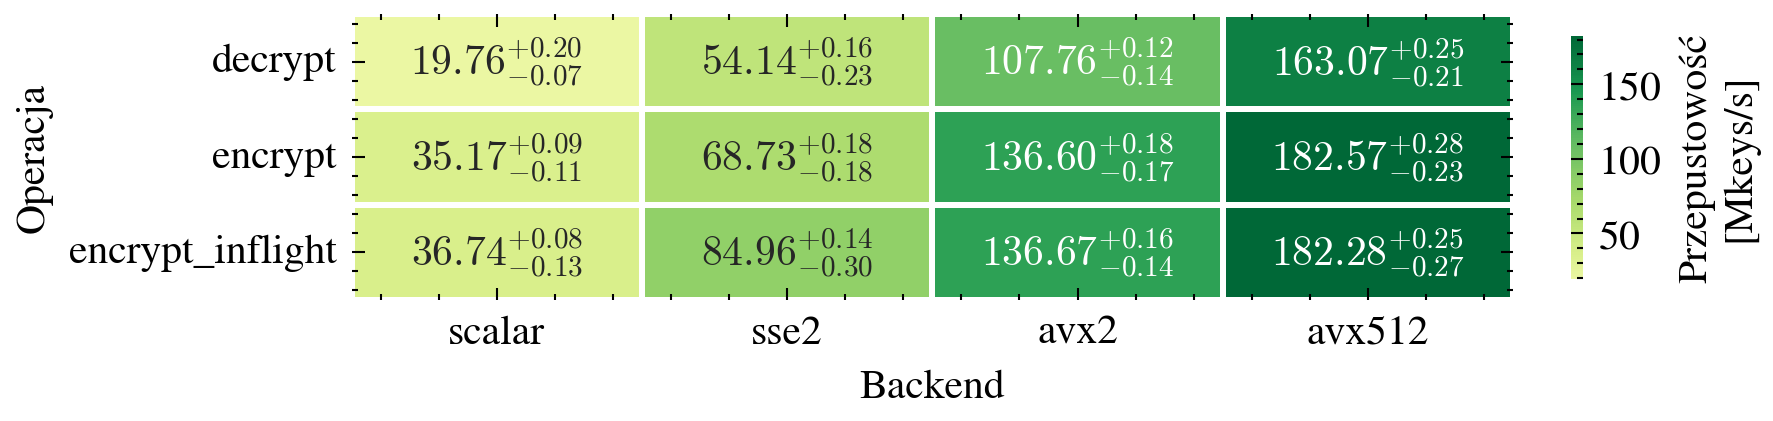

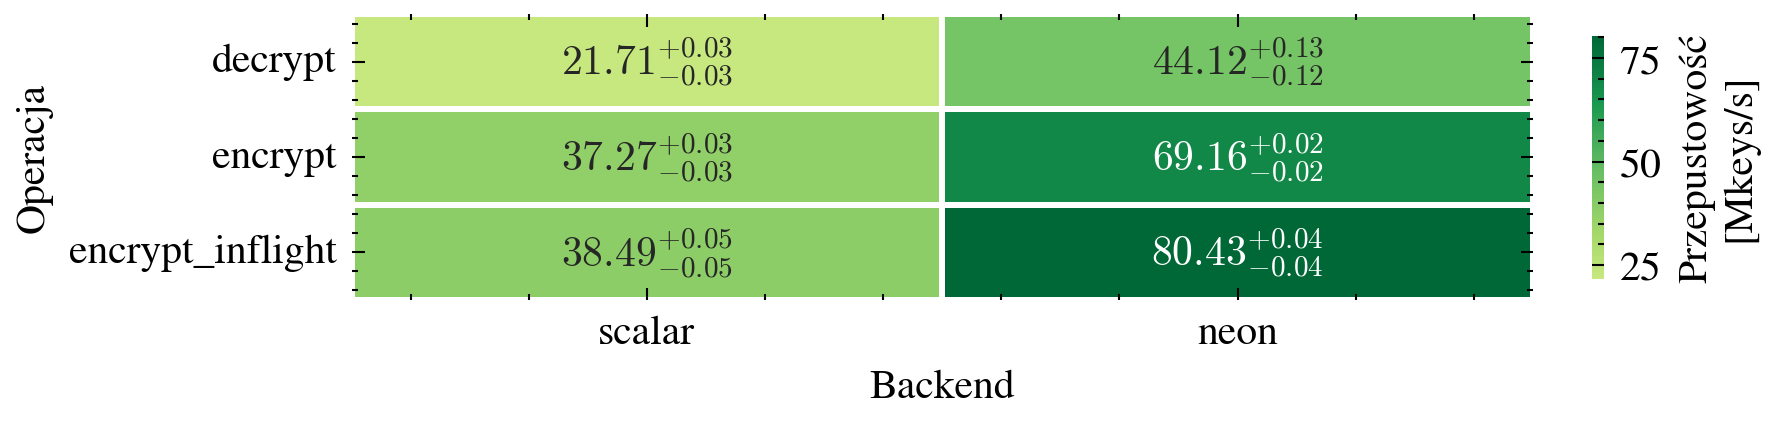

In [14]:
def plot_speck_heatmap(reg_df, backend_order, filename):
    val, up, dn = make_speck_pivot_mean(reg_df, backend_order, fmt='ci')

    data = val.T
    up, dn = up.T, dn.T

    annot = np.empty(data.shape, dtype=object)
    for i in range(data.shape[0]):
        for j in range(data.shape[1]):
            v = data.iloc[i, j]
            u, dd = up.iloc[i, j], dn.iloc[i, j]
            annot[i, j] = "" if pd.isna(v) else rf"${v:.2f}^{{+{u:.2f}}}_{{-{dd:.2f}}}$"

    with plt.style.context(['science', 'no-latex', 'bright']):
        fig, ax = plt.subplots(figsize=(FIG_WIDTH, FIG_HEIGHT_7), layout='constrained')

        sns.heatmap(
            data,
            ax=ax,
            cmap='RdYlGn',
            center=0,
            annot=annot,
            fmt='',
            linewidths=1.0,
            cbar_kws={'label': 'Przepustowość\n[Mkeys/s]', 'shrink': 0.85},
        )

        ax.set_xlabel("Backend")
        ax.set_ylabel('Operacja')

        plt.savefig(f'../svg/{filename}', facecolor='white')
        plt.show()


plot_speck_heatmap(speck_reg_x86, ['scalar', 'sse2', 'avx2', 'avx512'], 'speck_pivot_backend_heatmap_x86.svg')
plot_speck_heatmap(speck_reg_aarch64, ['scalar', 'neon'], 'speck_pivot_backend_heatmap_aarch64.svg')

In [15]:
speck_inflight_x86 = speck_reg_x86[speck_reg_x86['function'] == 'encrypt_inflight']
speck_inflight_aarch64 = speck_reg_aarch64[speck_reg_aarch64['function'] == 'encrypt_inflight']

In [16]:
def make_speck_backend_speedup(df, backend_order, fmt=False):
    version_order = ['32_64', '48_72', '48_96', '64_96', '64_128',
                     '96_96', '96_144', '128_128', '128_192', '128_256']

    d = df.copy()
    d['k_hi'] = d['keys_per_sec'] * d['time_per_iter_ns'] / d['ci_95_low_ns']
    d['k_lo'] = d['keys_per_sec'] * d['time_per_iter_ns'] / d['ci_95_high_ns']

    sc = d[d['backend'] == 'scalar'].set_index('version')
    sc_k  = sc['keys_per_sec']
    sc_lo = sc['k_lo']
    sc_hi = sc['k_hi']

    s = d[d['backend'] != 'scalar'].copy()
    s['speedup'] = s['keys_per_sec'] / s['version'].map(sc_k)
    s['sp_hi'] = s['k_hi'] / s['version'].map(sc_lo)
    s['sp_lo'] = s['k_lo'] / s['version'].map(sc_hi)
    s['up_pct'] = (s['sp_hi'] / s['speedup'] - 1.0) * 100
    s['dn_pct'] = (1.0 - s['sp_lo'] / s['speedup']) * 100

    s['backend'] = pd.Categorical(s['backend'], categories=backend_order, ordered=True)
    s['version'] = pd.Categorical(s['version'], categories=version_order, ordered=True)

    def piv(col):
        p = s.pivot_table(index='version', columns='backend', values=col, observed=True).reset_index()
        p.columns.name = None
        p['version'] = p['version'].astype(str).str.replace('_', '/', regex=False)
        return p.set_index('version')

    if fmt == 'ci':
        return piv('speedup'), piv('up_pct'), piv('dn_pct')
    return piv('speedup')

In [17]:
def merge_ci(x86, aarch64):
    return tuple(pd.merge(a, b, on='version', how='left') for a, b in zip(x86, aarch64))

sp_x86 = make_speck_backend_speedup(speck_inflight_x86, ['sse2', 'avx2', 'avx512'], fmt='ci')
sp_arm = make_speck_backend_speedup(speck_inflight_aarch64, ['neon'], fmt='ci')
speck_backend_speedup_ci = merge_ci(sp_x86, sp_arm)

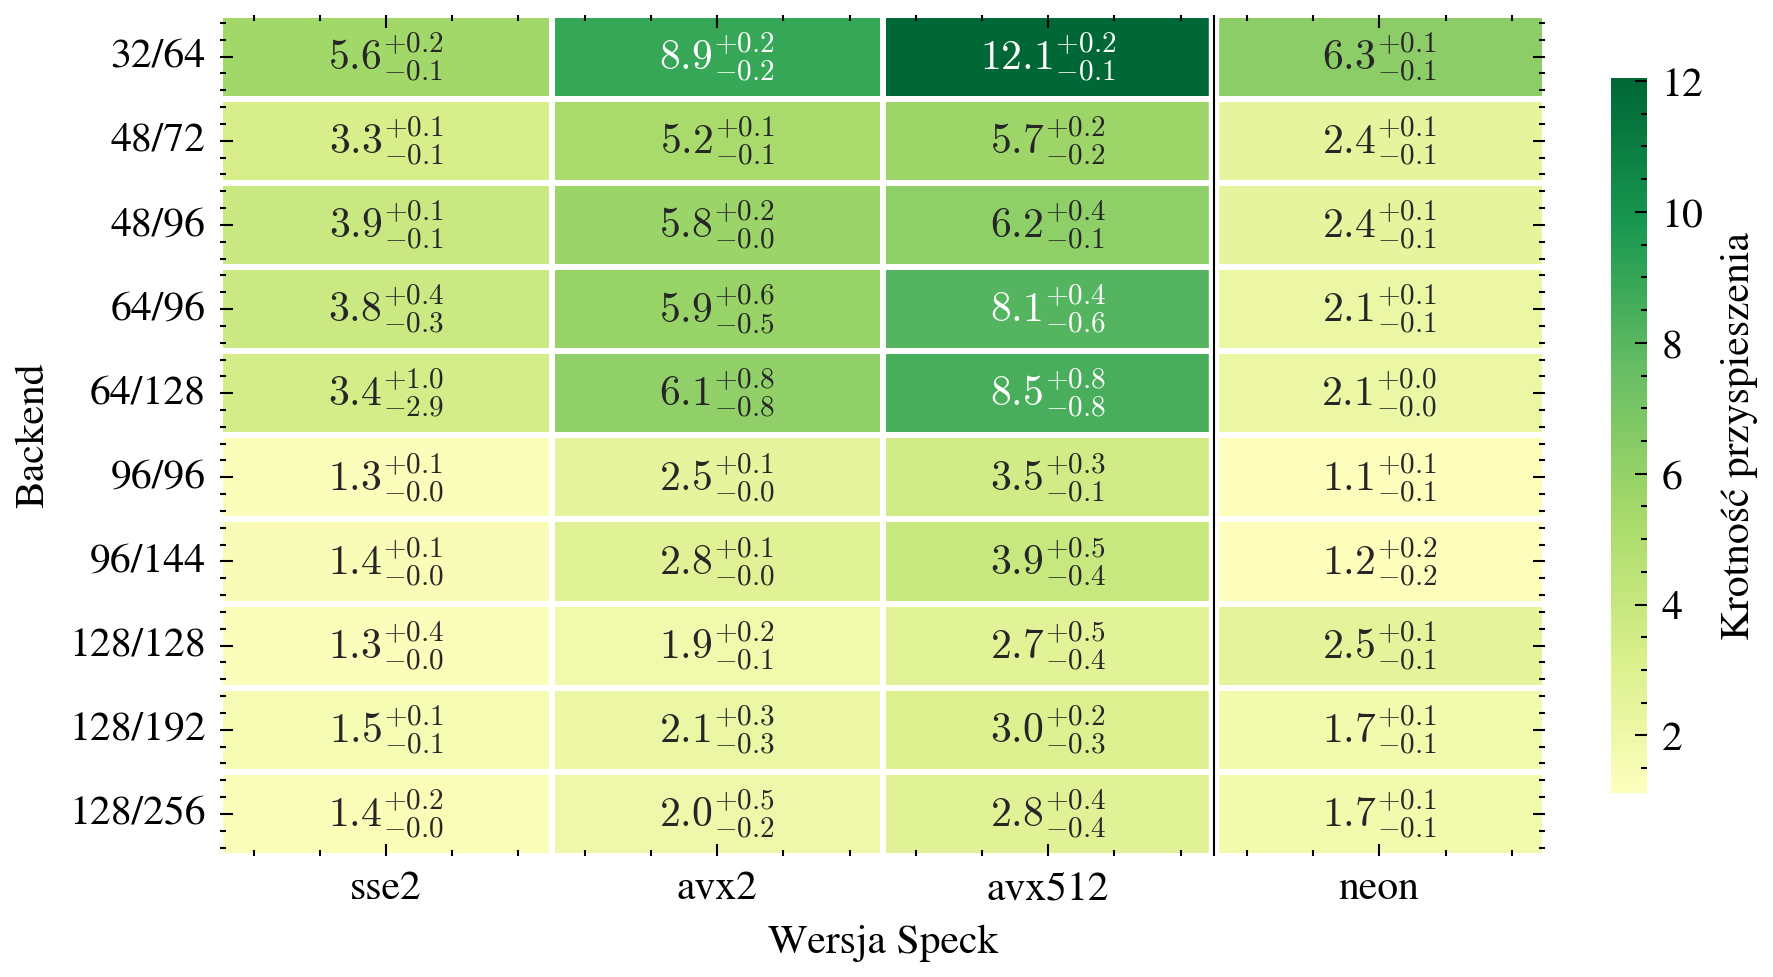

In [18]:
def plot_speck_backend_speedup(speedup_ci, filename, fig_height):
    val, up, dn = speedup_ci
    data = val

    annot = np.empty(data.shape, dtype=object)
    for i in range(data.shape[0]):
        for j in range(data.shape[1]):
            v = data.iloc[i, j]
            u, d_ = up.iloc[i, j], dn.iloc[i, j]
            if pd.isna(v):
                annot[i, j] = ""
            elif pd.isna(u) or pd.isna(d_):
                annot[i, j] = rf"${v:.2f}$"
            else:
                annot[i, j] = rf"${v:.1f}^{{+{u:.1f}}}_{{-{d_:.1f}}}$"

    with plt.style.context(['science', 'no-latex', 'bright']):
        fig, ax = plt.subplots(figsize=(FIG_WIDTH, fig_height), layout='constrained')

        sns.heatmap(
            data,
            ax=ax,
            annot=annot,
            fmt='',
            cmap='RdYlGn',
            center=1,
            linewidths=1.0,
            cbar_kws={'label': 'Krotność przyspieszenia', 'shrink': 0.85},
        )
        ax.set_xlabel('Wersja Speck')
        ax.set_ylabel('Backend')

        ax.axvline(x=3, color='white', linewidth=2.5)
        ax.axvline(x=3, color='black', linewidth=0.5)

        plt.setp(ax.get_xticklabels(), rotation=0)
        plt.setp(ax.get_yticklabels(), rotation=0)

        plt.savefig(f'../svg/{filename}', facecolor='white')
        plt.show()

plot_speck_backend_speedup(speck_backend_speedup_ci, 'speck_backend_speedup.svg', FIG_HEIGHT_3)

In [19]:
def get_engine(df):
    engine = df[df['benchmark'] == 'engine']
    engine = engine.drop(columns=['benchmark', 'unit', 'throughput_type', 'function'])
    engine['time_per_iter_ns'] = engine['sample_measured_value'] / engine['iteration_count']

    engine['keys_per_sec'] = (
        engine['throughput_num'] / (engine['time_per_iter_ns'] / 1e9)
    )

    return engine

In [20]:
engine_x86 = get_engine(criterion_x86)
engine_aarch64 = get_engine(criterion_aarch64)
print(engine_x86)

       row_index backend architecture  version  suffix  throughput_num  \
12000          0    sse2       x86_64  128_256     3.0        16777216   
12001          1    sse2       x86_64  128_256     3.0        16777216   
12002          2    sse2       x86_64  128_256     3.0        16777216   
12003          3    sse2       x86_64  128_256     3.0        16777216   
12004          4    sse2       x86_64  128_256     3.0        16777216   
...          ...     ...          ...      ...     ...             ...   
15595         25    avx2       x86_64    32_64     1.0             256   
15596         26    avx2       x86_64    32_64     1.0             256   
15597         27    avx2       x86_64    32_64     1.0             256   
15598         28    avx2       x86_64    32_64     1.0             256   
15599         29    avx2       x86_64    32_64     1.0             256   

       sample_measured_value  iteration_count  time_per_iter_ns  keys_per_sec  
12000            428488956.0   

In [21]:
engine_reg_x86 = regression(engine_x86, ['backend', 'architecture', 'version', 'suffix'])
engine_reg_x86

/home/jan/Developer/speck/analysis/.venv/lib/python3.14/site-packages/scipy/stats/_axis_nan_policy.py:592: RuntimeWarning: All `x` coordinates are identical.
  res = hypotest_fun_out(*samples, **kwds)
/home/jan/Developer/speck/analysis/.venv/lib/python3.14/site-packages/numpy/_core/fromnumeric.py:3824: RuntimeWarning: Mean of empty slice
  return _methods._mean(a, axis=axis, dtype=dtype,
/home/jan/Developer/speck/analysis/.venv/lib/python3.14/site-packages/numpy/_core/_methods.py:142: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)
/home/jan/Developer/speck/analysis/.venv/lib/python3.14/site-packages/scipy/stats/_stats_mstats_common.py:178: RuntimeWarning: invalid value encountered in sqrt
  sigma = np.sqrt(sigsq)


,backend,architecture,version,suffix,time_per_iter_ns,ci_95_low_ns,ci_95_high_ns,intercept_ns,r2,keys_per_sec,Mkeys_per_sec
0,avx2,x86_64,128_128,1.0,3.368687e+03,3.328413e+03,3.382755e+03,-7.591533e+05,0.999608,7.599400e+07,75.994002
1,avx2,x86_64,128_128,2.0,8.569310e+05,8.492455e+05,8.615243e+05,1.194354e+06,0.999678,7.647757e+07,76.477567
2,avx2,x86_64,128_128,3.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,avx2,x86_64,128_192,1.0,3.645387e+03,3.616008e+03,3.662131e+03,-2.589824e+06,0.999435,7.022573e+07,70.225735
4,avx2,x86_64,128_192,2.0,9.250515e+05,9.220417e+05,9.286860e+05,8.851378e+04,0.999932,7.084579e+07,70.845788
...,...,...,...,...,...,...,...,...,...,...,...
115,sse2,x86_64,96_144,2.0,1.598915e+06,1.594125e+06,1.604474e+06,-4.041542e+05,0.999891,4.098780e+07,40.987804
116,sse2,x86_64,96_144,3.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
117,sse2,x86_64,96_96,1.0,8.012702e+03,8.005528e+03,8.014761e+03,-1.689792e+05,0.999997,3.194927e+07,31.949273
118,sse2,x86_64,96_96,2.0,1.589330e+06,1.587089e+06,1.590506e+06,-5.945964e+05,0.999982,4.123498e+07,41.234977
